In [4]:
import numpy as np
import xarray as xr
import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw

import cartopy.crs as ccrs
import matplotlib.ticker as mticker

This code computes age and oxygen budgets for the various experiments and plots the budget figures. It relies heavily on our O2age_budget.py code, which is modified from a standard budget code for heat (thanks to miniufo's https://github.com/miniufo/notebooks/blob/master/Budget%20in%20MITgcm%20Part%20I.ipynb). One important modification is that we compute the "non-divergent" vertical and horizontal advection, for instance w*(dC/dz) rather than d/dz (wC); this is discussed in the manuscript and in this code, and it is important for reducing noise and highlighting dynamics in the plots.

Note that these budgets are perfectly balanced for interior cells, which is what is studied in this project, but that we don't have a surface flux term. You will want to double check that surface fluxes are represented properly to get the surface cells to balance properly as well (should be straightforward the necessary code, just a heads up!).

Diagnotiscs: When using the DIC and tracer packages in MITgcm, most of the required budget terms are already available as diagnostics, so you just need to output them (see our data.diagnostics file). Make sure to save snapshots of tracer value (not the budget terms) at the beginning and end of the intervals over which the budget terms are averaged (in this case, the beginning and end of the year). The snapshots are a straightforward diagnostic to add: use a negative value for time (see fileName(8) = 'Snaps' in data.diagnostics). The tricky part is the O2 biological source/sink term. Getting the O2 output requires modifying the MITgcm code (DIC_biotic_forcing.F) to save the oxygen change term as a diagnostic; we used the built-in user diagnostic UDIAG3. 

This script is written to use the .nc files that we have made available. If you're interested in the original version using direct binary output, see the other file. I've also left some code commented here. 

In [5]:
# Importing my budget codes to compute the cellwise budget from MITgcm output. 
#import O2age_budget  
#from O2age_budget import AgeBudgetND as AgeBud 

# slight updates to accomodate different variable names.
import O2age_budget_ncfiles 
from O2age_budget_ncfiles import AgeBudgetND as AgeBud


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99]


In [6]:
PacTrac_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-O2-Age-Tracers.nc'
PacTrac = xr.open_dataset(PacTrac_ncf)

PacSn_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-O2-Age-Snapshots.nc'
PacSn = xr.open_dataset(PacSn_ncf)

PacAgeBud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-Age-Budget.nc'
PacAgeBudterms = xr.open_dataset(PacAgeBud_ncf)

PacO2Bud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-O2-Budget.nc'
PacO2Budterms = xr.open_dataset(PacO2Bud_ncf)

PacPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-Physical.nc'
PacPh = xr.open_dataset(PacPhnc)

Pac3d = xr.merge([PacTrac, PacAgeBudterms, PacO2Budterms, PacPh])

# Same thing for Southern-4C 
SOTrac_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-O2-Age-Tracers.nc'
SOTrac = xr.open_dataset(SOTrac_ncf)

SOSn_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-O2-Age-Snapshots.nc'
SOSn = xr.open_dataset(SOSn_ncf)

SOAgeBud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-Age-Budget.nc'
SOAgeBudterms = xr.open_dataset(SOAgeBud_ncf)

SOO2Bud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-O2-Budget.nc'
SOO2Budterms = xr.open_dataset(SOO2Bud_ncf)

SOPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-Physical.nc'
SOPh = xr.open_dataset(SOPhnc)

SO3d = xr.merge([SOTrac, SOAgeBudterms, SOO2Budterms, SOPh])

## same for Control run. 

CtlTrac_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Age-Tracers.nc'
CtlTrac = xr.open_dataset(CtlTrac_ncf)
CtlSn_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Age-Snapshots.nc'
CtlSn = xr.open_dataset(CtlSn_ncf)
CtlAgeBud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Age-Budget.nc'
CtlAgeBudterms = xr.open_dataset(CtlAgeBud_ncf)
CtlO2Bud_ncf = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Budget.nc'
CtlO2Budterms = xr.open_dataset(CtlO2Bud_ncf)
CtlPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
CtlPh = xr.open_dataset(CtlPhnc)
Ctl3d = xr.merge([CtlTrac, CtlAgeBudterms, CtlO2Budterms, CtlPh])


In [9]:
PacAge = AgeBud(Pac3d.sel(time = range(91,101)), PacSn.sel(time = range(90,101)))
PacAge.calc_all()

/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a

In [13]:
PacSn.sel(time = range(90,101)).time

<xarray.DataArray 'time' (time: 11)> Size: 88B
array([ 90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100])
Coordinates:
    iter     (time) int64 88B ...
  * time     (time) int64 88B 90 91 92 93 94 95 96 97 98 99 100

In [6]:
## This is code to get the budget terms straight from the binary output. 


# First just want to load the data. 

#myYr = np.arange(1,100) # here loading everything. 
#print(myYr)
##myIts = 1080000 + 720*myYr
#myIts = 2880000 + 720*myYr
##print(myIts)
#SnIts = np.concatenate(([myIts[0]-720], myIts)) # snapshot times. 

#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
#folPac = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/Pacfade_4C/'
#folSO = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/SOfade_4C/'
#fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'
#
##folSOfade = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/SOfade_4C/'
### 
#Pac3d = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = [ 'DynDiag3d','AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#vol = Pac3d.drF*Pac3d.hFacC*Pac3d.rA
#SO3d = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#Ctl3d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#SO3d = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#
#PacSn = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
#SOSn = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
#CtlSn = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
#


In [7]:
## Calculate all the budgets here. 

# Select only the a certain time range. 
tran = range(81,101) # first value is year 1. 
snran = range(80,101)

PacAge = AgeBud(Pac3d.sel(time = tran), PacSn.sel(time = snran))
PacAge.calc_all()
SOAge = AgeBud(SO3d.sel(time = tran), SOSn.sel(time = snran))
SOAge.calc_all()
CtlAge = AgeBud(Ctl3d.sel(time = tran), CtlSn.sel(time = snran))
CtlAge.calc_all()

PacO2 = O2age_budget_ncfiles.OxygenBudget(Pac3d.sel(time = tran), PacSn.sel(time = snran))
PacO2.calc_all()
SOO2 = O2age_budget_ncfiles.OxygenBudget(SO3d.sel(time = tran), SOSn.sel(time = snran))
SOO2.calc_all()
CtlO2 = O2age_budget_ncfiles.OxygenBudget(Ctl3d.sel(time = tran), CtlSn.sel(time = snran))
CtlO2.calc_all()

/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a

In [30]:
## taking the means of the budget terms for Pacific section!
# Note that we only use the last decade! 
# there's a better way to do this it turns out .. 

xran = range(64,80) # 64,80 is 180-135 W.
yran = range(20,53)
zran = range(17)
tran = range(10,20) # last 10 years of the simulation. 

# really weird naming convention, but it works... A is Pacific. No reason to do this, see below!
#PoAw = PacO2.terms.advr_nd_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Po0w = CtlO2.terms.advr_nd_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PoAadv = PacO2.terms.advct_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Po0adv = CtlO2.terms.advct_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PoAdiff =  PacO2.terms.diffu_O2.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Po0diff = CtlO2.terms.diffu_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PoAtend = PacO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Po0tend = CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PoAbio = PacO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Po0bio = CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PlAw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Pl0w = CtlAge.terms.advr_nd_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PlAadv = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Pl0adv = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#
#PlAtot = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time') + PacAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')
#Pl0tot = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time') + CtlAge.terms.diffu_Age.isel(XC = xran, YC = yran, Z= zran, time = tran).mean('XC').mean('time')

# weighting just removes the land boxes. 
PacO2xm = PacO2.terms.isel( XC = xran, YC = yran, Z= zran, time = tran).weighted(Pac3d.hFacC).mean('XC').mean('time')
CtlO2xm = CtlO2.terms.isel( XC = xran, YC = yran, Z= zran, time = tran).weighted(Pac3d.hFacC).mean('XC').mean('time')
PacAgexm = PacAge.terms.isel( XC = xran, YC = yran, Z= zran, time = tran).weighted(Pac3d.hFacC).mean('XC').mean('time')
CtlAgexm = CtlAge.terms.isel( XC = xran, YC = yran, Z= zran, time = tran).weighted(Pac3d.hFacC).mean('XC').mean('time')

#PlAwg = Pacwgrad.isel( XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#PlBwg = SOwgrad.isel( XC = xran, YC = yran, Z= zran).mean('XC').mean('time')

In [24]:
## For the contours of panels a-b, we need the total change (as shown in Fig 5b, e). 


## using the direct output. 
#myYrten = np.arange(90,100)
##print(myYr)
#myItstend = 2880000 + 720*myYrten
##folPac = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CPac_try1/'
#PacTend = xmitgcm.open_mdsdataset(folPac, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myItstend.tolist(), ignore_unknown_vars = True)
##fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
##fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'
#CtlTend = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myItstend.tolist(), ignore_unknown_vars = True)

#o2Pact = xr.where(PacTend.TRAC05 ==0, np.nan, PacTend.TRAC05).mean('time')
#agePact= xr.where(PacTend.TRAC11 ==0, np.nan, PacTend.TRAC11).mean('time')
#o2cont= xr.where(CtlTend.TRAC05 ==0, np.nan, CtlTend.TRAC05).mean('time')
#agecont= xr.where(CtlTend.TRAC11 ==0, np.nan, CtlTend.TRAC11).mean('time')

xran = range(64,80) # 180-135 W; 54,74 is what I used in Fig 2.
yran = range(20,53)
zran = range(17)
# here calculating the tendency just using the nc file
o2Pact = PacTrac.Oxygen.sel(time = range(91,101)).mean('time')
o2cont = CtlTrac.Oxygen.sel(time = range(91,101)).mean('time')
agePact = PacTrac.Age.sel(time = range(91,101)).mean('time')
agecont = CtlTrac.Age.sel(time = range(91,101)).mean('time')

o2Pac90 = o2Pact.isel(XC = xran, YC = yran, Z= zran).mean('XC') - o2cont.isel(XC = xran, YC = yran, Z= zran).mean('XC')
agePac90 = agePact.isel(XC = xran, YC = yran, Z= zran).mean('XC') - agecont.isel(XC = xran, YC = yran, Z= zran).mean('XC')

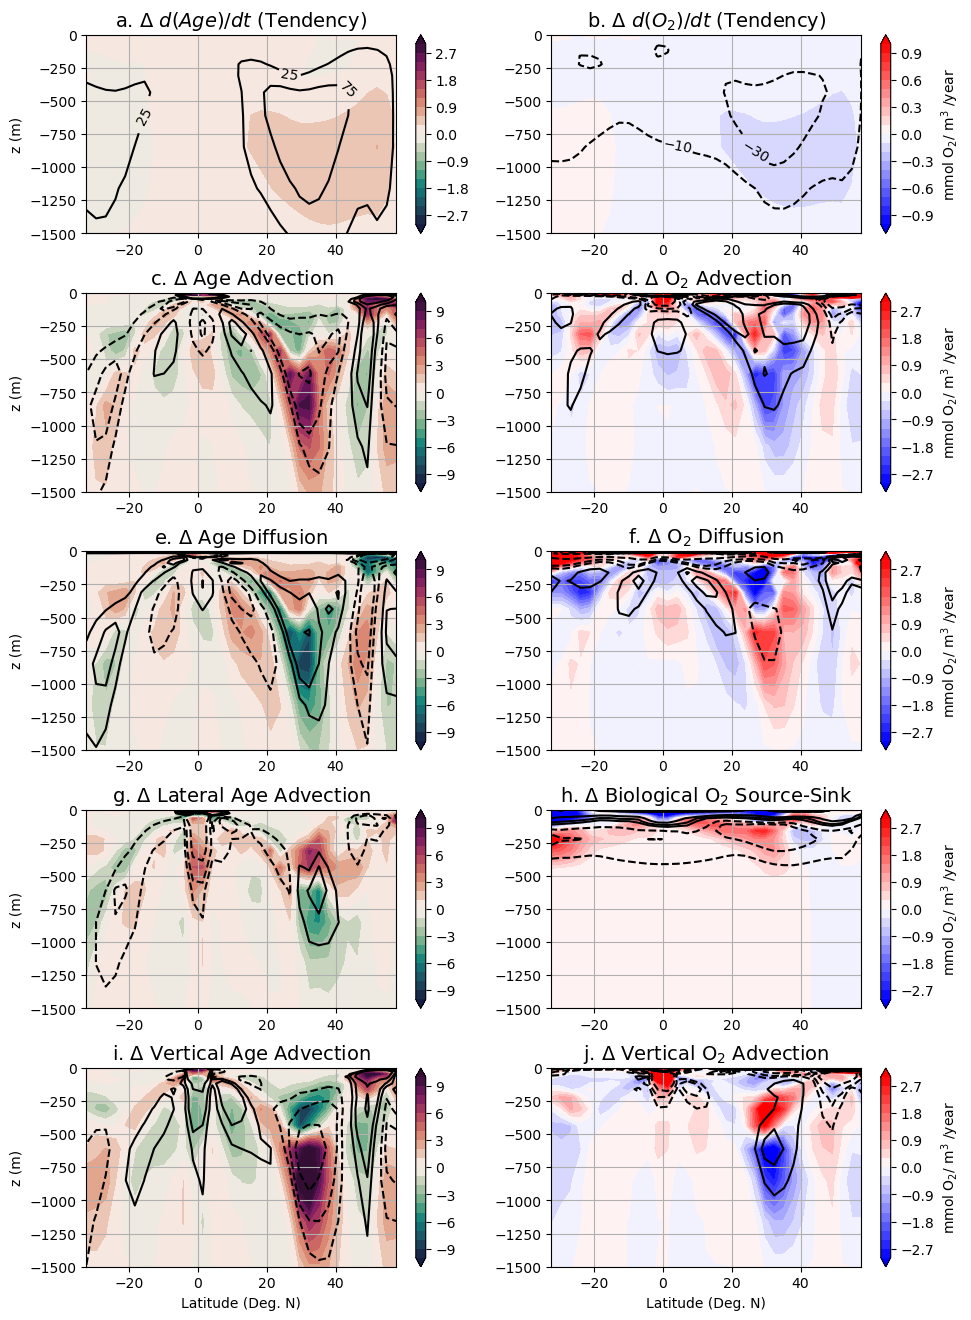

In [25]:
## Pacific zonal mean budget with both AGE and OXYGEN
# oxygen will be more interesting to the BGC people 

# note that the budget output is daily, so we multiply by 360 for the annual rate. 
# this makes the age unitless (years/year)

# Rewritten more clearly (without the cryptic variable names). 

import cmocean
agemap = cmocean.cm.curl
o2map = 'bwr'

zdep = 1500
vm = 10
vmo = 3
vmot = 1
vmat = 3

fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(11,16))
plt.rcParams['text.usetex'] = False

ageclev = [-20,-10, -5, 5, 10, 20]
o2clev = [-12,-6, -3, 3, 6, 12]
lw = 1.5

tfon = 14
Diag3d = Pac3d

E = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PacAgexm.Tend_Age- CtlAgexm.Tend_Age)  , vmin = -vmat, vmax = vmat, levels = np.linspace(-vmat, vmat,21), cmap = agemap, extend = 'both')
aget1 = axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], agePac90, levels = [25, 75],colors= 'k')
aget1.clabel()#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
axs[0,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PacO2xm.Tend_O2 - CtlO2xm.Tend_O2), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = o2map, extend = 'both')
o2t1 = axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran],1000*o2Pac90, levels = [-30, -10, 10], colors= 'k')
o2t1.clabel()
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb = plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[0,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,1].grid()


axs[0,1].set_title('b. $\Delta$ $d(O_2)/dt$ (Tendency)', fontsize = tfon)
axs[0,0].set_title('a. $\Delta$ $d(Age)/dt$ (Tendency)', fontsize = tfon)



C = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PacAgexm.advct_Age - CtlAgexm.advct_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.advct_Age)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(C, ax= axs[1,0])
axs[1,0].set_ylim([-zdep,0])
#axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PlAtot - Pl0tot),levels = [1.2, 2.4], colors='black', linewidths=1)
axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PacO2xm.advct_O2- CtlO2xm.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.advct_O2), levels = o2clev, colors= 'k')

Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[1,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,1].grid()


axs[1,1].set_title('d. $\Delta$ O$_2$ Advection', fontsize = tfon)# $-div $[O_2*u]$ (O$_2$ Advection)')
axs[1,0].set_title('c. $\Delta$ Age Advection', fontsize = tfon) #-div $[Age*u]$ (Age Advection)')


C = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PacAgexm.diffu_Age - CtlAgexm.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.diffu_Age)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(C, ax= axs[2,0])
axs[2,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,0].grid()

M = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PacO2xm.diffu_O2 - CtlO2xm.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.diffu_O2), levels = o2clev, colors= 'k')
Mcb = plt.colorbar(D, ax= axs[2,1])
Mcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[2,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,1].grid()


axs[2,1].set_title('f. $\Delta$ O$_2$ Diffusion', fontsize = tfon)
axs[2,0].set_title('e. $\Delta$ Age Diffusion', fontsize = tfon)



A = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PacAgexm.advct_Age - PacAgexm.advr_nd_Age - CtlAgexm.advct_Age + CtlAgexm.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[3,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*(CtlAgexm.advct_Age - CtlAgexm.advr_nd_Age)  , levels = ageclev, colors='k', linewidths = lw)
plt.colorbar(A, ax= axs[3,0])
axs[3,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PacO2xm.Bio_O2- CtlO2xm.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[3,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.Bio_O2), levels = o2clev, colors= 'k')
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[3,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[3,1].set_title('h. $\Delta$ Biological O$_2$ Source-Sink', fontsize = tfon)
axs[3,0].set_title('g. $\Delta$ Lateral Age Advection', fontsize = tfon) #'$\Delta$  $[u *d(Age)/dx + v*d(Age)/dy]$ (Horiz. Adv.)')

I = axs[4,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(PacAgexm.advr_nd_Age - CtlAgexm.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
axs[4,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.advr_nd_Age)  , levels = ageclev, colors='k', linewidths = lw)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(I, ax= axs[4,0])
axs[4,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[4,0].grid()

J = axs[4,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PacO2xm.advr_nd_O2- CtlO2xm.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
axs[4,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.advr_nd_O2), levels = o2clev, colors= 'k')
Jcb = plt.colorbar(J, ax= axs[4,1])
Jcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[4,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[4,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[4,1].set_title('j. $\Delta$ Vertical O$_2$ Advection', fontsize = tfon)#'$\Delta$   $[w *d(O_2)/dz]$(Vertical Oxygen Advection)')
axs[4,0].set_title('i. $\Delta$ Vertical Age Advection', fontsize = tfon)


#F = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(PoAtend - Po0tend), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = o2map, extend = 'both')

#consider cutting this off at 1500 m instead? 
#axs[2,0].set_xlabel('Deg. N') 
axs[4,1].set_xlabel('Latitude (Deg. N)') 
axs[4,0].set_xlabel('Latitude (Deg. N)') 

axs[0,0].set_ylabel('z (m)')
axs[1,0].set_ylabel('z (m)')
axs[2,0].set_ylabel('z (m)')
axs[3,0].set_ylabel('z (m)')
axs[4,0].set_ylabel('z (m)')
plt.subplots_adjust(hspace=0.3)

#plt.savefig('../eps_figures/budget_sections_meancontours_4-30.eps', bbox_inches="tight")

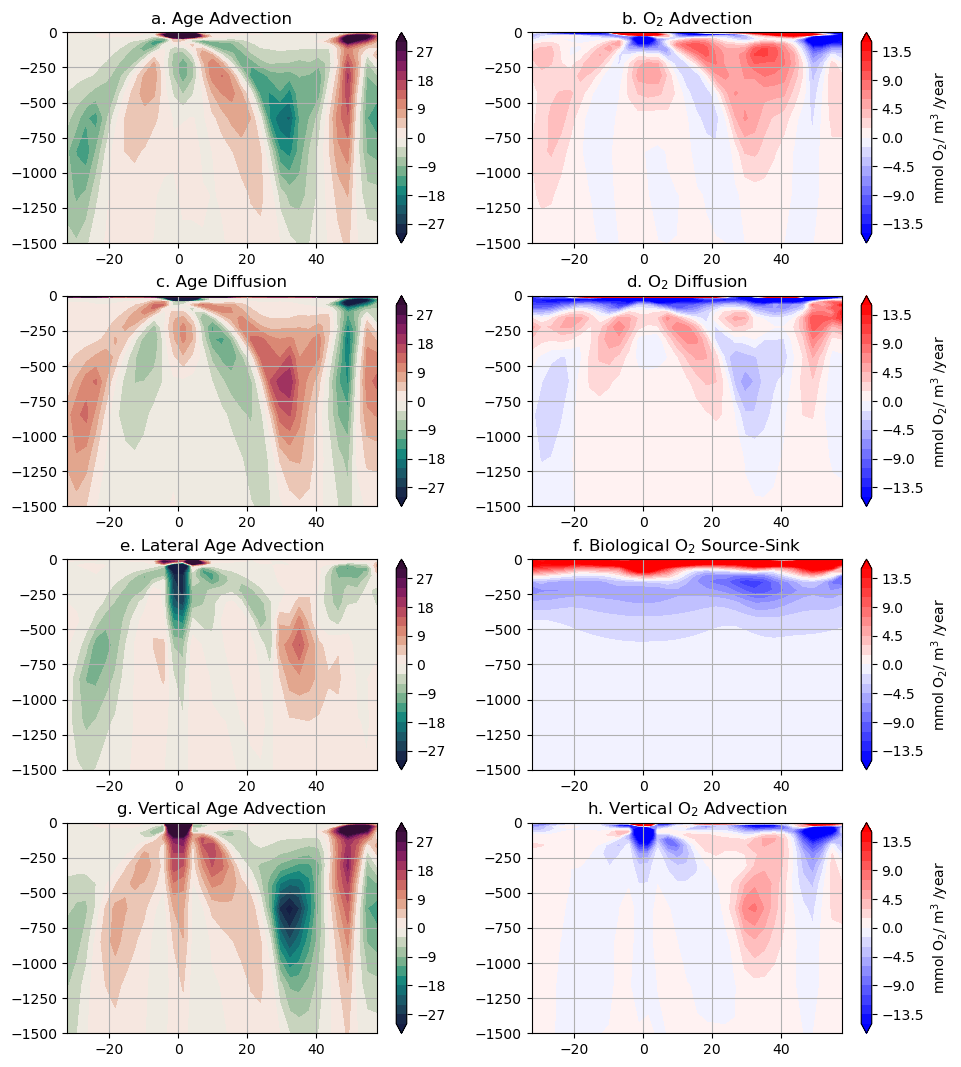

In [32]:
## OK here I want to try just redoing the previous plot but only for the control state (supplemental!) 

import cmocean
agemap = cmocean.cm.curl
o2map = 'bwr'

zdep = 1500
vm = 30
vmo = 15
vmot = 1
vmat = 3

fig, axs = plt.subplots(ncols=2 , nrows=4, figsize=(11,13))
plt.rcParams['text.usetex'] = False

Diag3d = Pac3d




C = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.advct_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[0,0])
axs[0,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,0].grid()

D = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*( CtlO2xm.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[0,1])
Dcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[0,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0,1].grid()


axs[0,1].set_title('b. O$_2$ Advection')# $-div $[O_2*u]$ (O$_2$ Advection)')
axs[0,0].set_title('a. Age Advection') #-div $[Age*u]$ (Age Advection)')


C = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(CtlAgexm.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[1,0])
axs[1,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,0].grid()

M = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(D, ax= axs[1,1])
Mcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[1,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1,1].grid()


axs[1,1].set_title('d. O$_2$ Diffusion')
axs[1,0].set_title('c. Age Diffusion')



A = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.advct_Age - CtlAgexm.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[2,0])
axs[2,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,0].grid()

B = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[2,1])
Bcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[2,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[2,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[2,1].set_title('f. Biological O$_2$ Source-Sink')
axs[2,0].set_title('e. Lateral Age Advection') #'$\Delta$  $[u *d(Age)/dx + v*d(Age)/dy]$ (Horiz. Adv.)')

I = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*(CtlAgexm.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(I, ax= axs[3,0])
axs[3,0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,0].grid()

J = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Jcb = plt.colorbar(J, ax= axs[3,1])
Jcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[3,1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[3,1].grid()


#axs[3,1].set_title('$\Delta$  $[w *d(O_2)/dz]$')
axs[3,1].set_title('h. Vertical O$_2$ Advection')#'$\Delta$   $[w *d(O_2)/dz]$(Vertical Oxygen Advection)')
axs[3,0].set_title('g. Vertical Age Advection')

#letters = ['a','b','c','d','e','f','g','h','i','j']
#for i in range(4):
#    for j in range(2):
#        axs[i,j].text(0.07, 0.1, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')



plt.subplots_adjust(hspace=0.25)
# plt.savefig('../eps_figures/mean_budget_section_4-30.eps')


## Bonus figure to show budget closure

If you're reading this, you might be interested that the budget closed (which we extensively tested when deriving the budget). Here's a brief figure to show that a given budget closes. The residual is essentially 0 (note the colorbar limits) in the interior ocean.

Clearly the surface cell does not close because we're not including surface fluxes among the budget terms. Also, there may be some funkiness at XC = 127 or 0 (at the boundary in the Atlantic). But for the most part, the closure below the surface is exact. 

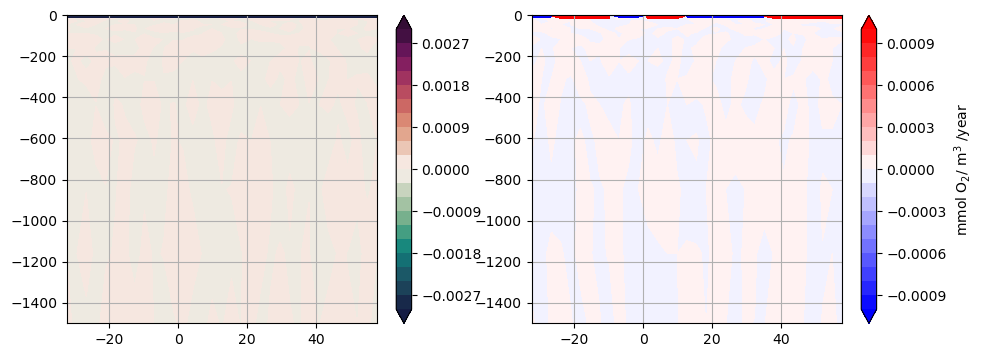

In [33]:

# select zonal means of some region and some experiment (using the script above).
ABud = CtlAgexm 
OBud = CtlO2xm

zdep = 1500
vm = 0.03#30 , so colorbar is showing 1000x the term sizes
vmo = 0.01#15, so the colorbar is showing 1500x the term sizes.
vmot = 1
vmat = 3


fig, axs = plt.subplots(ncols=2 , nrows=1, figsize=(11,4))
plt.rcParams['text.usetex'] = False

Diag3d = Pac3d

C = axs[0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 360*( CtlAgexm.Tend_Age - CtlAgexm.advct_Age - CtlAgexm.diffu_Age)-1 , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[0])
axs[0].set_ylim([-zdep,0])
#axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0].grid()

D = axs[1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*360*(CtlO2xm.Tend_O2 -CtlO2xm.advct_O2 - CtlO2xm.diffu_O2 - CtlO2xm.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = o2map,extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[1])
Dcb.set_label('mmol O$_2$/ m$^3$ /year')
axs[1].set_ylim([-zdep,0])
#axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1].grid()

## Southern-4C budget in map form

In [16]:
# I can do the depth-average much more easily this way. xarray is nice. 
# All we're doing is averaging the budget terms and plotting. 

xran = range(42,105)
yran = range(12,53)
zran = range(8,13) # 195 to 985 m. 
deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran) # calculate the depth of each grid level.

tmpSOO2 = SOO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
SOO2map = tmpSOO2.sum('Z')/deps.sum('Z')
tmpSOAge = SOAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
SOAgemap = tmpSOAge.sum('Z')/deps.sum('Z')

tmpCtlO2 = CtlO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
CtlO2map = tmpCtlO2.sum('Z')/deps.sum('Z')
tmpCtlAge = CtlAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
CtlAgemap = tmpCtlAge.sum('Z')/deps.sum('Z')

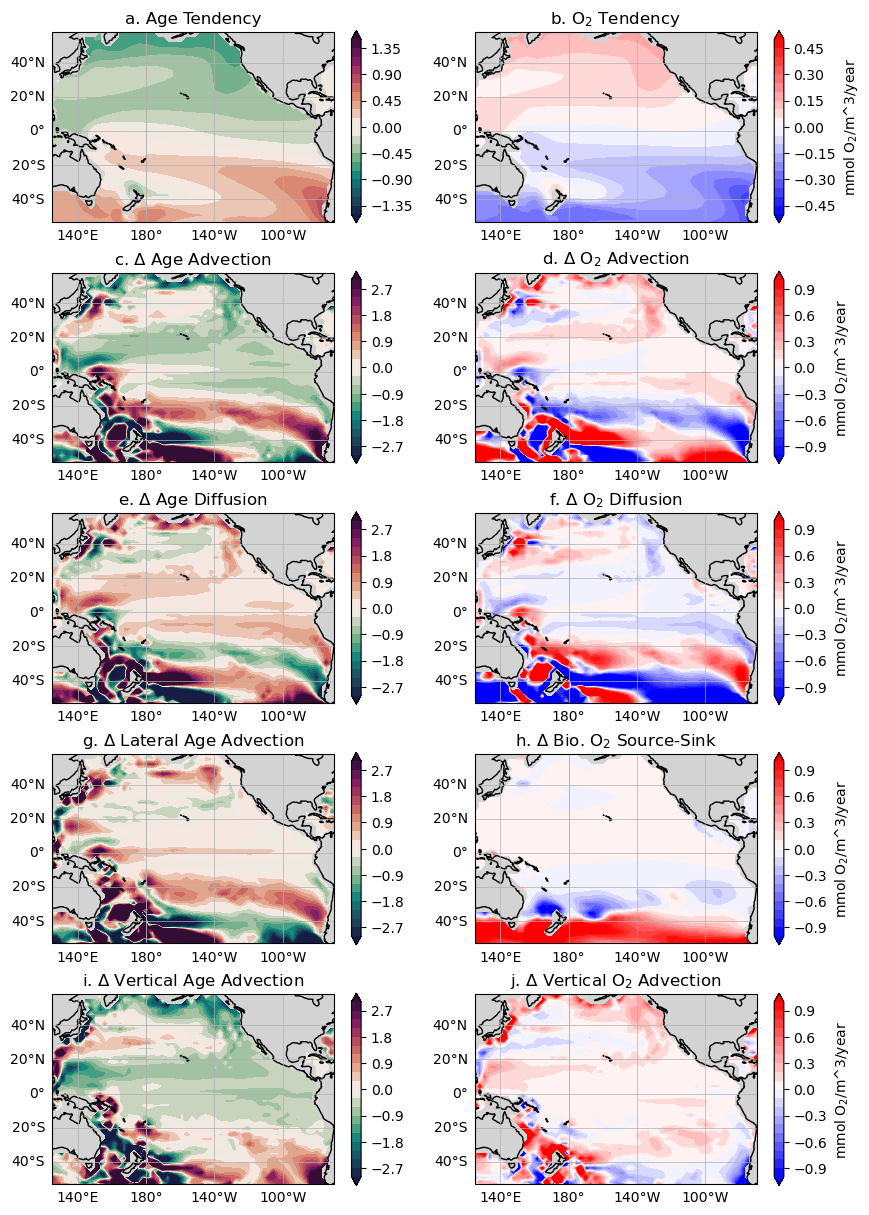

In [19]:
# Figure 10 plotting

import cmocean
agemap = cmocean.cm.curl
omap = 'bwr'

Diag3d = Pac3d

vm= 3
vmo = 1
vmt = 1.5
vmot = 0.5

ForcO = SOO2map
ForcA = SOAgemap
CtlO = CtlO2map
CtlA = CtlAgemap
tfon  =12
proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(10,15), subplot_kw={'projection': proj})
plt.rcParams['text.usetex'] = False

E = axs[0,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.Tend_Age -CtlA.Tend_Age)  , vmin = -vmt, vmax = vmt, levels = np.linspace(-vmt, vmt,21), cmap = agemap, extend = 'both', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.Tend_O2- CtlO.Tend_O2), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb=plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/m^3/year')
#axs[0,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,1].grid()


axs[0,0].set_title('a. Age Tendency', fontsize = tfon)
axs[0,1].set_title('b. O$_2$ Tendency', fontsize = tfon)



C = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*( ForcA.advct_Age- CtlA.advct_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ccb = plt.colorbar(C, ax= axs[1,0])

#axs[1,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.advct_O2- CtlO.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/m^3/year')

#axs[1,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,1].grid()


axs[1,0].set_title('c. $\Delta$ Age Advection', fontsize = tfon)
axs[1,1].set_title('d. $\Delta$ O$_2$ Advection', fontsize = tfon)


C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.diffu_Age - CtlA.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[2,0])
#axs[2,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,0].grid()

D = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.diffu_O2 - CtlO.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ecb = plt.colorbar(D, ax= axs[2,1])
Ecb.set_label('mmol O$_2$/m^3/year')
#axs[2,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,1].grid()


axs[2,0].set_title('e. $\Delta$ Age Diffusion', fontsize = tfon)
axs[2,1].set_title('f. $\Delta$ O$_2$ Diffusion', fontsize = tfon)

A = axs[3,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advct_Age - ForcA.advr_nd_Age - CtlA.advct_Age + CtlA.advr_nd_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[3,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.Bio_O2 - CtlO.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()

axs[3,0].set_title('g. $\Delta$ Lateral Age Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')
axs[3,1].set_title('h. $\Delta$ Bio. O$_2$ Source-Sink', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')



M = axs[4,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advr_nd_Age - CtlA.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(M, ax= axs[4,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

N = axs[4,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.advr_nd_O2- CtlO.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ncb = plt.colorbar(N, ax= axs[4,1])
Ncb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()
axs[4,0].set_extent([140, 20, 30, 60], crs = proj)
axs[4,0].set_title('i. $\Delta$ Vertical Age Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')
axs[4,1].set_title('j. $\Delta$ Vertical O$_2$ Advection', fontsize = tfon) #$\Delta [w *d(Age)/dz]$')

#plt.savefig('Age_Budget_maps.eps')
#letters = ['a','b','c','d','e','f','g','h','i','j']
for i in range(5):
    for j in range(2):
        #axs[i,j].text(0.84, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_extent([110, -55, -53, 58], crs = proj)
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 40))
        axs[i,j].set_facecolor('lightgray')

plt.subplots_adjust(hspace=0.25)
#consider cutting this off at 1500 m instead? 
#plt.savefig('eps_figures/budget_SOmaps8-19.eps')
#plt.savefig('../eps_figures/budget_SOmaps4-30.eps', bbox_inches="tight")



## Budget timeseries

This requires the full timeseries of the budget terms, so you'll need to change the time range that you're computing the budget for (early in the code when calc_all() is run). 

Other than that, it's just averaging over the masked volume and plotting. 

In [18]:
# this depends on vol being defined as OMZ. 

# just a short code to do the weighted average of a masked region. 

def o2regts(trac, mask, depr): 
    Tvol = vol.isel(Z =depr)*trac.isel(Z= depr)
    Tvolz = Tvol.sum('Z')*mask
    volz = vol.isel(Z=depr).sum('Z')*mask
    tracts = Tvolz.sum('XC').sum('YC')/volz.sum('XC').sum('YC')
    return tracts
    

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


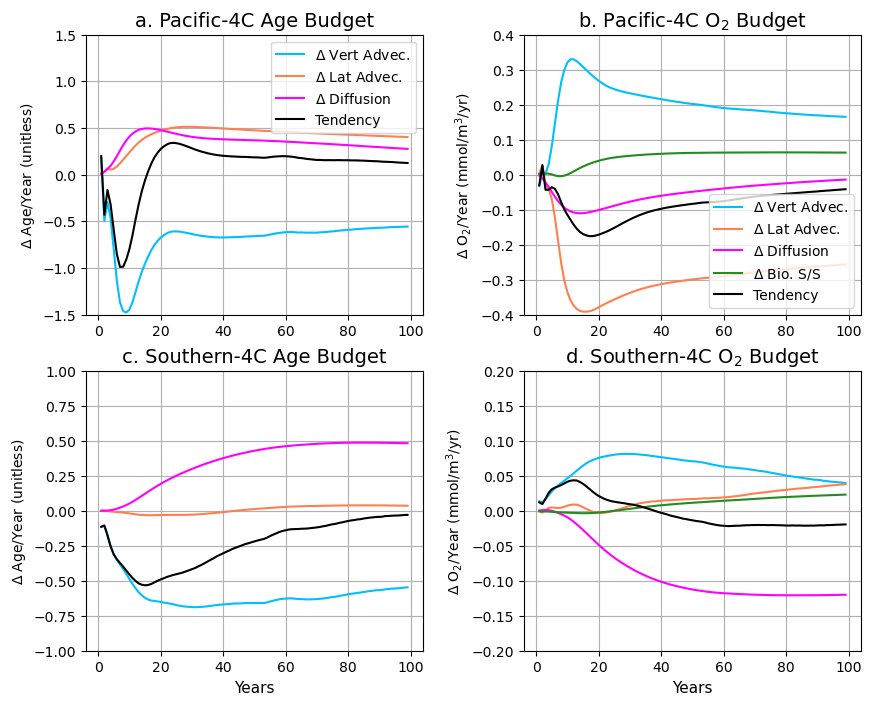

In [23]:
#oldmask = xr.load_dataarray('../Yohei_2018/old_tropical_mask.nc')

## building the timeseries figure that I'm excited about. 
# Version 1, with just the budget terms. 

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [10,8]) 
oldmask = xr.load_dataarray('../Yohei_2018/OMZmask.nc')
plt.subplots_adjust(wspace=0.3)
tfon = 14
yrx = np.arange(1,100)

myZ = np.arange(8,13)

## Pac O2
toPl2 = o2regts(PacO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[0,1].plot(yrx, 360*1000*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(PacO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*(toPl - toPl2), label = '$\Delta$ Lat Advec.', color='coral')

toPl3 = (o2regts(PacO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl3, label = '$\Delta$ Diffusion', color = 'magenta')

toPl5 = (o2regts(PacO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl5, label = '$\Delta$ Bio. S/S', color = 'forestgreen')
toPl4 = (o2regts(PacO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[0,1].legend( loc='lower right', fontsize = 10)
axs[0,1].grid()
axs[0,1].set_ylim([-0.4,0.4])
axs[0,1].set_title('b. Pacific-4C O$_2$ Budget', fontsize = tfon)
axs[0,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)


## SO O2
toPl2 = o2regts(SOO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[1,1].plot(yrx, 360*1000*toPl2, label = 'Vert adv.', color = 'deepskyblue')
toPl = (o2regts(SOO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(SOO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(SOO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(SOO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[1,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)

axs[1,1].grid()
axs[1,1].set_ylim([-0.2,0.2])
axs[1,1].set_title('d. Southern-4C O$_2$ Budget', fontsize = tfon)
axs[1,1].set_xlabel('Years', fontsize = 11)
#plt.legend(ax = axs[0,1], loc='lower right')

## Pac-4c age
toPl2 = o2regts(PacAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[0,0].plot(yrx, 360*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(PacAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*(toPl - toPl2), label =  '$\Delta$ Lat Advec.', color='coral')

toPl3 = (o2regts(PacAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl3, label = '$\Delta$ Diffusion', color = 'magenta')
toPl4 = (o2regts(PacAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[0,0].grid()
axs[0,0].set_ylim([-1.5,1.5])
axs[0,0].legend( loc='upper right', fontsize = 10)
axs[0,0].set_title('a. Pacific-4C Age Budget', fontsize = tfon)
axs[0,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)


## SO Age
toPl2 = o2regts(SOAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[1,0].plot(yrx, 360*toPl2, label = '$\Delta$ Vert Advec.', color = 'deepskyblue')
toPl = (o2regts(SOAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*(toPl - toPl2), label =  '$\Delta$ Lat Advec.', color='coral')
toPl3 = (o2regts(SOAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl3, label = 'Diffusion', color = 'magenta')
toPl4 = (o2regts(SOAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[1,0].set_ylim([-1,1])
axs[1,0].grid()
axs[1,0].set_title('c. Southern-4C Age Budget', fontsize = tfon)
axs[1,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)
axs[1,0].set_xlabel('Years', fontsize = 11)

#plt.legend(loc = 'upper right')
#plt.grid()
#plt.title('ETP Age change under SO-4C')

#plt.grid()
#plt.title('ETP O2 change under Pacific-4C')

#letters = ['a','b','c','d']
#for i in range(2):
#    for j in range(2):
#        axs[i,j].text(0.05, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

#plt.savefig('../eps_figures/budget_timeseries4-30.eps', bbox_inches="tight")



In [22]:
SOAge.terms.Tend_Age.shape

(99, 23, 64, 128)

## Supplementary Mean Budget figures

In [6]:
folGl = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4Cstep_try1/'
folNA = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CNA_try1/'
folOtho = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/OthO4C_try1/'

NA3d = xmitgcm.open_mdsdataset(folNA, grid_dir = fol3, prefix = [ 'DynDiag3d','AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#vol = Pac3d.drF*Pac3d.hFacC*Pac3d.rA
Gl3d = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#Ctl3d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
#Low3d = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)

NASn = xmitgcm.open_mdsdataset(folNA, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)
GlSn = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)

Otho3d = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d', 'O2Budget3d', 'DICDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
OthoSn = xmitgcm.open_mdsdataset(folOtho, grid_dir = fol3, prefix = ['Snaps'], iters = SnIts.tolist(), ignore_unknown_vars = True)





In [7]:
NAAge = AgeBud(NA3d, NASn)
NAAge.calc_all()
GlAge = O2age_budget.AgeBudgetND(Gl3d, GlSn)
GlAge.calc_all()
OthoAge = AgeBud(Otho3d, OthoSn)
OthoAge.calc_all()

GlO2 = O2age_budget.OxygenBudget(Gl3d, GlSn)
GlO2.calc_all()
NAO2 = O2age_budget.OxygenBudget(NA3d, NASn)
NAO2.calc_all()
OthoO2 = O2age_budget.OxygenBudget(Otho3d, OthoSn)
OthoO2.calc_all()


/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a

In [60]:
xran = range(42,105)
yran = range(12,53)
zran = range(8,13)


tmpPacO2 = PacO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PacO2map = tmpPacO2.sum('Z')/deps.sum('Z')
tmpPacAge = PacAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PacAgemap = tmpPacAge.sum('Z')/deps.sum('Z')


tmpGlO2 = GlO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
GlO2map = tmpGlO2.sum('Z')/deps.sum('Z')
tmpGlAge = GlAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
GlAgemap = tmpGlAge.sum('Z')/deps.sum('Z')

tmpNAO2 = NAO2.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
NAO2map = tmpNAO2.sum('Z')/deps.sum('Z')
tmpNAAge = NAAge.terms.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
NAAgemap = tmpNAAge.sum('Z')/deps.sum('Z')

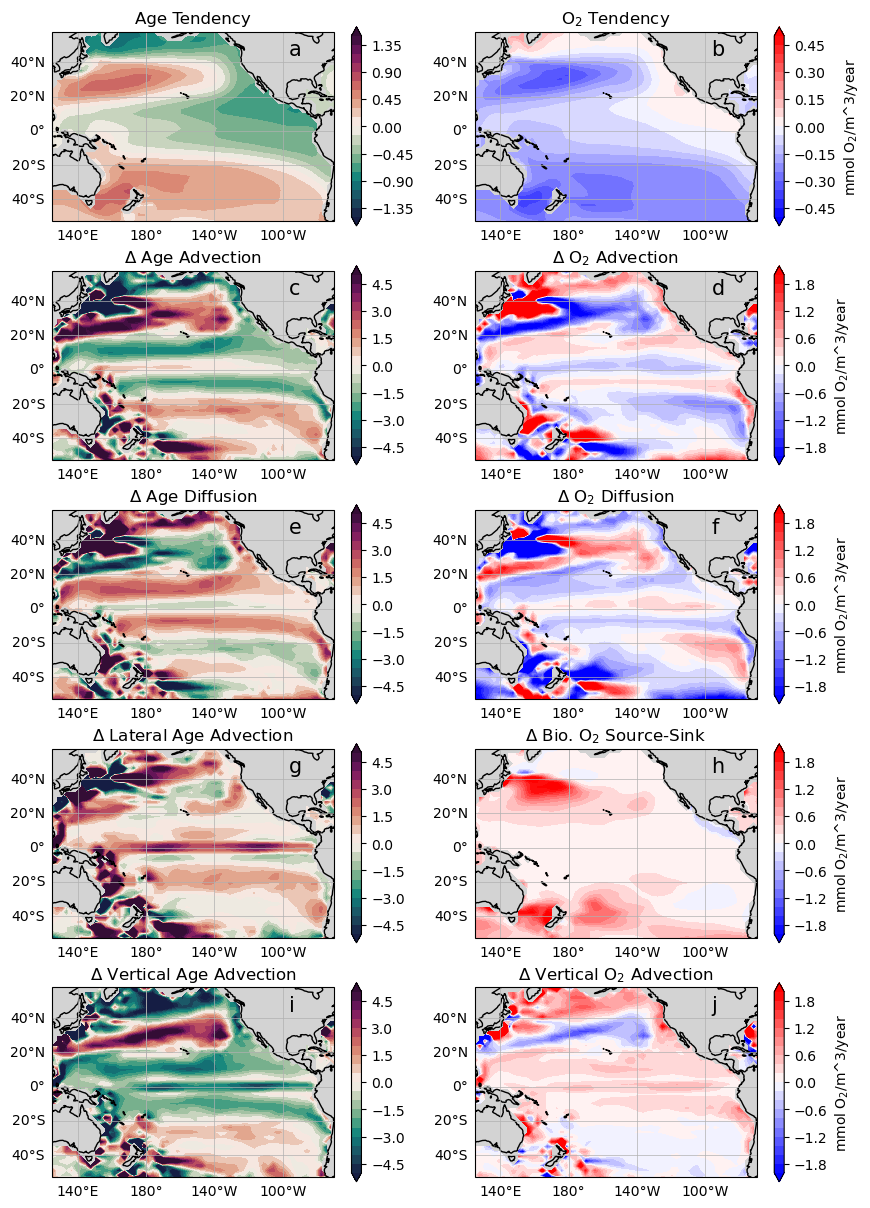

In [62]:
# OK trying to rewrite the Pacific version to make life way easier. 

## here's the plotting one ... 

import cmocean
agemap = cmocean.cm.curl
omap = 'bwr'

Diag3d = Pac3d

vm= 5
vmo = 2
vmt = 1.5
vmot = 0.5

ForcO = GlO2map
ForcA = GlAgemap
CtlO = CtlO2map
CtlA = CtlAgemap


# this is truly not working. OK not a priority!! 
proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(ncols=2 , nrows=5, figsize=(10,15), subplot_kw={'projection': proj})
plt.rcParams['text.usetex'] = False

E = axs[0,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.Tend_Age -CtlA.Tend_Age)  , vmin = -vmt, vmax = vmt, levels = np.linspace(-vmt, vmt,21), cmap = agemap, extend = 'both', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(E, ax= axs[0,0])
#axs[0,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,0].grid()

F = axs[0,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.Tend_O2- CtlO.Tend_O2), vmin = -vmot, vmax = vmot, levels = np.linspace(-vmot, vmot,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Fcb=plt.colorbar(F, ax= axs[0,1])
Fcb.set_label('mmol O$_2$/m^3/year')
#axs[0,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[0,1].grid()


axs[0,0].set_title('Age Tendency')
axs[0,1].set_title('O$_2$ Tendency')



C = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*( ForcA.advct_Age- CtlA.advct_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ccb = plt.colorbar(C, ax= axs[1,0])

#axs[1,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,0].grid()

D = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*360*(ForcO.advct_O2- CtlO.advct_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Dcb = plt.colorbar(D, ax= axs[1,1])
Dcb.set_label('mmol O$_2$/m^3/year')

#axs[1,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[1,1].grid()


axs[1,0].set_title('$\Delta$ Age Advection')
axs[1,1].set_title('$\Delta$ O$_2$ Advection')


C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.diffu_Age - CtlA.diffu_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(C, ax= axs[2,0])
#axs[2,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,0].grid()

D = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.diffu_O2 - CtlO.diffu_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ecb = plt.colorbar(D, ax= axs[2,1])
Ecb.set_label('mmol O$_2$/m^3/year')
#axs[2,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[2,1].grid()


axs[2,0].set_title('$\Delta$ Age Diffusion')
axs[2,1].set_title('$\Delta$ O$_2$ Diffusion')

A = axs[3,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advct_Age - ForcA.advr_nd_Age - CtlA.advct_Age + CtlA.advr_nd_Age), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[3,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

B = axs[3,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.Bio_O2 - CtlO.Bio_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Bcb = plt.colorbar(B, ax= axs[3,1])
Bcb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()

axs[3,0].set_title('$\Delta$ Lateral Age Advection') #$\Delta [w *d(Age)/dz]$')
axs[3,1].set_title('$\Delta$ Bio. O$_2$ Source-Sink') #$\Delta [w *d(Age)/dz]$')



M = axs[4,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*(ForcA.advr_nd_Age - CtlA.advr_nd_Age)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(M, ax= axs[4,0])
#axs[3,0].set_ylim([-2000,0])
#axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,0].grid()

N = axs[4,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 360*1000*(ForcO.advr_nd_O2- CtlO.advr_nd_O2), vmin = -vmo, vmax = vmo, levels = np.linspace(-vmo, vmo,21), cmap = omap,extend = 'both',transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Ncb = plt.colorbar(N, ax= axs[4,1])
Ncb.set_label('mmol O$_2$/m^3/year')
#axs[3,1].set_ylim([-2000,0])
#axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
#axs[3,1].grid()
axs[4,0].set_extent([140, 20, 30, 60], crs = proj)
axs[4,0].set_title('$\Delta$ Vertical Age Advection') #$\Delta [w *d(Age)/dz]$')
axs[4,1].set_title('$\Delta$ Vertical O$_2$ Advection') #$\Delta [w *d(Age)/dz]$')

#plt.savefig('Age_Budget_maps.eps')
letters = ['a','b','c','d','e','f','g','h','i','j']
for i in range(5):
    for j in range(2):
        axs[i,j].text(0.84, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_extent([110, -55, -53, 58], crs = proj)
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 40))
        axs[i,j].set_facecolor('lightgray')
#consider cutting this off at 1500 m instead? 
#plt.savefig('eps_figures/budget_SOmaps8-19.eps')
#plt.savefig('eps_figures/budget_SOmaps10-8_v2.eps')
#plt.savefig('../eps_figures/budget_Glmaps11-14.eps')



In [2]:
45678

45678

In [ ]:
## old version of budget map code, for the record

# ## Calculating the maps needed for Southern Ocean oxygen
# here we're using the entire time period, because it better shows tendency...
xran = range(42,105)
yran = range(12,53)
zran = range(8,13)

#PlSO = ageSO.isel( XC = xran, YC = yran, Z= zran).mean('Z')
deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran)
#tmpPaw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOw = SOO2.terms.advr_nd_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmp0w = CtlO2.terms.advr_nd_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps

PoSOw = tmpSOw.sum('Z')/deps.sum('Z')
#PPacw = tmpPaw.sum('Z')/deps.sum('Z')
Po0w = tmp0w.sum('Z')/deps.sum('Z')

# advection
tmpSOv = SOO2.terms.advct_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  
tmp0v = CtlO2.terms.advct_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOv = tmpSOv.sum('Z')/deps.sum('Z')
Po0v = tmp0v.sum('Z')/deps.sum('Z')

# diffusion
tmpSOd = SOO2.terms.diffu_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0d =  CtlO2.terms.diffu_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOd = tmpSOd.sum('Z')/deps.sum('Z')
Po0d = tmp0d.sum('Z')/deps.sum('Z')

# tendency
tmpSOt = SOO2.terms.Tend_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0t =  CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOt = tmpSOt.sum('Z')/deps.sum('Z')
Po0t = tmp0t.sum('Z')/deps.sum('Z')

# biology!
tmpSOb = SOO2.terms.Bio_O2.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0b =  CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PoSOb = tmpSOb.sum('Z')/deps.sum('Z')
Po0b = tmp0b.sum('Z')/deps.sum('Z')

#PoAtend = PacO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#Po0tend = CtlO2.terms.Tend_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#
#PoAbio = PacO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')
#Po0bio = CtlO2.terms.Bio_O2.isel(XC = xran, YC = yran, Z= zran).mean('XC').mean('time')

## Age calculated below.

deps = Pac3d.drF.isel(Z=zran)*Pac3d.hFacC.isel(XC = xran, YC = yran, Z= zran)
#tmpPaw = PacAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOw = SOAge.terms.advr_nd_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmp0w = CtlAge.terms.advr_nd_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps
PlSOw = tmpSOw.sum('Z')/deps.sum('Z')
Pl0w = tmp0w.sum('Z')/deps.sum('Z')

#tmpPav = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmpSOv = SOAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  
tmp0v = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PlSOv = tmpSOv.sum('Z')/deps.sum('Z')
#PlPacv = tmpPav.sum('Z')/deps.sum('Z')
Pl0v = tmp0v.sum('Z')/deps.sum('Z')

#tmpPat = PacAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps +PacAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps
tmpSOt = SOAge.terms.advct_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps  +SOAge.terms.diffu_Age.isel( XC = xran, YC = yran, Z= zran).mean('time')*deps 
tmp0t = CtlAge.terms.advct_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps +CtlAge.terms.diffu_Age.isel(XC = xran, YC = yran, Z= zran).mean('time')*deps 
PlSOt = tmpSOt.sum('Z')/deps.sum('Z')
#PlPact = tmpPat.sum('Z')/deps.sum('Z')
Pl0t = tmp0t.sum('Z')/deps.sum('Z')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


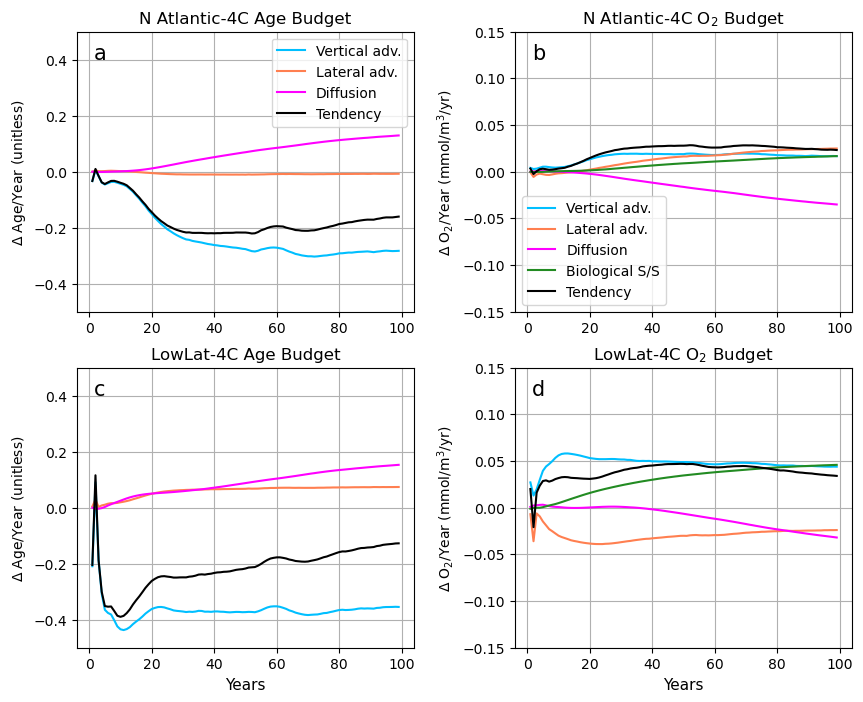

In [14]:
#oldmask = xr.load_dataarray('../Yohei_2018/old_tropical_mask.nc')

## timeseries figure, now for LowLat and North Atlantic for supplement

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = [10,8]) 
oldmask = xr.load_dataarray('../Yohei_2018/OMZmask.nc')
plt.subplots_adjust(wspace=0.3)

yrx = np.arange(1,100)

myZ = np.arange(8,13)
toPl2 = o2regts(NAO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[0,1].plot(yrx, 360*1000*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(NAO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(NAO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(NAO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(NAO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[0,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[0,1].legend( loc='lower left', fontsize = 10)
axs[0,1].grid()
axs[0,1].set_ylim([-0.15,0.15])
axs[0,1].set_title('N Atlantic-4C O$_2$ Budget')
axs[0,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)


## SO age 
toPl2 = o2regts(OthoO2.terms.advr_nd_O2 - CtlO2.terms.advr_nd_O2, oldmask, myZ)
axs[1,1].plot(yrx, 360*1000*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(OthoO2.terms.advct_O2 - CtlO2.terms.advct_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*(toPl - toPl2), label = 'Lateral adv.', color='coral')

toPl3 = (o2regts(OthoO2.terms.diffu_O2 - CtlO2.terms.diffu_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl3, label = 'Diffusion', color = 'magenta')

toPl5 = (o2regts(OthoO2.terms.Bio_O2 - CtlO2.terms.Bio_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl5, label = 'Biological S/S', color = 'forestgreen')
toPl4 = (o2regts(OthoO2.terms.Tend_O2 - CtlO2.terms.Tend_O2, oldmask, myZ))
axs[1,1].plot(yrx, 360*1000*toPl4, label = 'Tendency', color = 'black')
axs[1,1].set_ylabel('$\\Delta$ O$_2$/Year (mmol/m$^3$/yr)', fontsize = 10)

axs[1,1].grid()
axs[1,1].set_ylim([-0.15,0.15])
axs[1,1].set_title('LowLat-4C O$_2$ Budget')
axs[1,1].set_xlabel('Years', fontsize = 11)
#plt.legend(ax = axs[0,1], loc='lower right')

## Pac-4c age
toPl2 = o2regts(NAAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[0,0].plot(yrx, 360*toPl2, label = 'Vertical adv.', color = 'deepskyblue')
toPl = (o2regts(NAAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*(toPl - toPl2), label =  'Lateral adv.', color='coral')

toPl3 = (o2regts(NAAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl3, label = 'Diffusion', color = 'magenta')
toPl4 = (o2regts(NAAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[0,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[0,0].grid()
axs[0,0].set_ylim([-0.5,0.5])
axs[0,0].legend( loc='upper right', fontsize = 10)
axs[0,0].set_title('N Atlantic-4C Age Budget')
axs[0,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)

toPl2 = o2regts(OthoAge.terms.advr_nd_Age - CtlAge.terms.advr_nd_Age, oldmask, myZ)
axs[1,0].plot(yrx, 360*toPl2, label = 'vertical adv', color = 'deepskyblue')
toPl = (o2regts(OthoAge.terms.advct_Age - CtlAge.terms.advct_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*(toPl - toPl2), label =  'lateral adv', color='coral')
toPl3 = (o2regts(OthoAge.terms.diffu_Age - CtlAge.terms.diffu_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl3, label = 'diffusion', color = 'magenta')
toPl4 = (o2regts(OthoAge.terms.Tend_Age - CtlAge.terms.Tend_Age, oldmask, myZ))
axs[1,0].plot(yrx, 360*toPl4, label =  'Tendency', color = 'black')
axs[1,0].set_ylim([-0.5,0.5])
axs[1,0].grid()
axs[1,0].set_title('LowLat-4C Age Budget')
axs[1,0].set_ylabel('$\\Delta$ Age/Year (unitless)', fontsize = 10)
axs[1,0].set_xlabel('Years', fontsize = 11)

#plt.legend(loc = 'upper right')
#plt.grid()
#plt.title('ETP Age change under SO-4C')

#plt.grid()
#plt.title('ETP O2 change under Pacific-4C')

#plt.savefig('../eps_figures/supp_budget_ts11-30.eps')

letters = ['a','b','c','d']
for i in range(2):
    for j in range(2):
        axs[i,j].text(0.05, 0.96, letters[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')




In [15]:
ls ../eps_figures/.

7-9-2025/                                 Fig1_MITgcm_maps_812.eps
Agemap8-14.eps                            Fig1_MITgcm_maps_812.pdf
Agemap8-14.pdf                            Fig1_MITgcm_maps_8-27.eps
Agemaps7-21.eps                           Fig1_MITgcm_maps.eps
Agemaps7-21.pdf                           Fig1_MITgcm_maps.pdf
age_o2_aou_sections11-14.eps              Fig1_with_obs10-31.eps
age_o2_aou_sections8-14.eps               Fig1_with_obs11-21.eps
age_o2_aou_sections8-14.pdf               Fig_with_obs10-31.eps
AgeO2maps11-14.eps                        mean_budget_section_8-27.eps
AgeO2maps8-19.eps                         myfigure.pdf
AgeO2maps8-19.pdf                         O2maps7-21.eps
budget_Glmaps11-14.eps                    O2maps7-21.pdf
budget_Pacmaps11-14.eps                   O2maps8-14.eps
budget_sections7-25.eps                   O2maps8-14.pdf
budget_sections7-25.pdf                   Obs_O2_10-9.eps
budget_sections8-12.eps                   Obs_supp_O2_11-21.eps
bu